# Exercise 3

In this exercise, you will analyse a dataset obtained from the London transport system (TfL). The data is in a filled called `tfl_readership.csv` (comma-separated-values format).  As in Exercise 2, we will load and view the data using  `pandas`.

In [2]:
# If you are running this on Google Colab, uncomment and run the following lines; otherwise ignore this cell
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import math
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [5]:
# Load data
df_tfl = pd.read_csv('/content/drive/MyDrive/IB-Data-Science/Exercises/tfl_ridership.csv')
# If running on Google Colab change path to '/content/drive/MyDrive/IB-Data-Science/Exercises/tfl_ridership.csv'

df_tfl.head(13)

,Year,Period,Start,End,Days,Bus cash (000s),Bus Oyster PAYG (000s),Bus Contactless (000s),Bus One Day Bus Pass (000s),Bus Day Travelcard (000s),...,Tube Contactless (000s),Tube Day Travelcard (000s),Tube Season Travelcard (000s),Tube Other incl free (000s),Tube Total (000s),TfL Rail (000s),Overground (000s),DLR (000s),Tram (000s),Air Line (000s)
0,2000/01,P 01,01 Apr '00,29 Apr '00,29d,884,0,0,210,231,...,0,655,1066,200,2509,0,0,96,45.8,0.0
1,2000/01,P 02,30 Apr '00,27 May '00,28d,949,0,0,214,205,...,0,605,1168,217,2598,0,0,93,46.5,0.0
2,2000/01,P 03,28 May '00,24 Jun '00,28d,945,0,0,209,221,...,0,650,1154,212,2623,0,0,98,47.1,0.0
3,2000/01,P 04,25 Jun '00,22 Jul '00,28d,981,0,0,216,241,...,0,708,1196,214,2761,0,0,105,50.8,0.0
4,2000/01,P 05,23 Jul '00,19 Aug '00,28d,958,0,0,225,248,...,0,730,1165,165,2643,0,0,103,50.3,0.0
5,2000/01,P 06,20 Aug '00,16 Sep '00,28d,984,0,0,243,236,...,0,702,1164,151,2608,0,0,100,49.2,0.0
6,2000/01,P 07,17 Sep '00,14 Oct '00,28d,1001,0,0,205,216,...,0,639,1286,196,2763,0,0,107,48.8,0.0
7,2000/01,P 08,15 Oct '00,11 Nov '00,28d,979,0,0,199,221,...,0,668,1298,220,2819,0,0,113,51.5,0.0
8,2000/01,P 09,12 Nov '00,09 Dec '00,28d,971,0,0,184,212,...,0,640,1302,242,2839,0,0,114,54.0,0.0
9,2000/01,P 10,10 Dec '00,06 Jan '01,28d,912,0,0,192,211,...,0,631,993,195,2359,0,0,90,55.3,0.0


Each row of our data frame represents the average daily ridership over a 28/29 day period for various types of transport and tickets (bus, tube etc.).  We have used the `.head()` command to display the top 13 rows of the data frame (corresponding to one year).  Focusing on the "Tube Total" column, notice the dip in ridership in row 9 (presumably due to Christmas/New Year's), and also the slight dip during the summer (rows 4,5).

In [6]:
#df_tfl.sample(3)  #random sample of 3 rows
df_tfl.tail(3)  #last 3 rows

,Year,Period,Start,End,Days,Bus cash (000s),Bus Oyster PAYG (000s),Bus Contactless (000s),Bus One Day Bus Pass (000s),Bus Day Travelcard (000s),...,Tube Contactless (000s),Tube Day Travelcard (000s),Tube Season Travelcard (000s),Tube Other incl free (000s),Tube Total (000s),TfL Rail (000s),Overground (000s),DLR (000s),Tram (000s),Air Line (000s)
242,2018/19,P 09,11 Nov '18,08 Dec '18,28d,0,1110,1089,0,41,...,1399,249,1017,334,4221,996,557,355,84.1,2.6
243,2018/19,P 10,09 Dec '18,05 Jan '19,28d,0,1001,949,0,38,...,1110,242,632,259,3279,750,414,270,66.3,3.2
244,2018/19,P 11,06 Jan '19,02 Feb '19,28d,0,1036,1075,0,30,...,1310,204,924,305,3809,929,517,333,79.3,2.3


The dataframe contains $N=245$ counting periods (of 28/29 days each) from 1 April 2000 to  2 Feb 2019. We now define a numpy array consisting of the values in the ' Tube Total (000s)' column:

In [37]:
yvals = np.array(df_tfl['Tube Total (000s)'])
N = np.size(yvals)
xvals = np.linspace(1,N,N) #an array containing the values 1,2....,N
print(N)

245


We now have a time series consisting of points $(x_i,y_i)$, for $i = 1, \ldots, N$, where $y_i$ is the average daily tube rideship in counting period $x_i = i$.

## 3a) Plot the data in a scatterplot

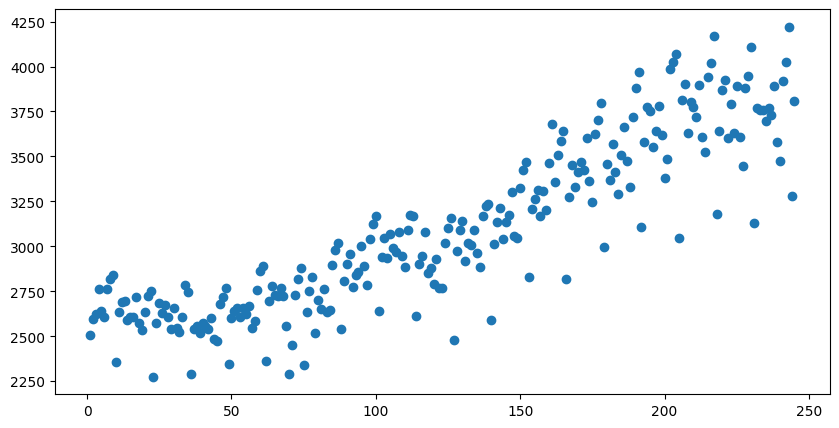

In [10]:
#Your code for scatterplot here
plt.rcParams['figure.figsize'] = [10, 5]
plt.scatter(xvals, yvals)
plt.show()

## 3b) Fit a linear model $f(x) = \beta_0 + \beta_1 x$ to the data

- Print the values of the regression coefficients $\beta_0, \beta_1$ determined using least-squares.
- Plot the fitted model and the scatterplot on the same plot.
- Compute and print the **MSE** and the $R^2$ coefficient for the fitted model.

All numerical outputs should be displayed to three decimal places.

beta_0 = 2367.382, beta_1 = 5.939
MSE = 45323.636
R2 = 0.796


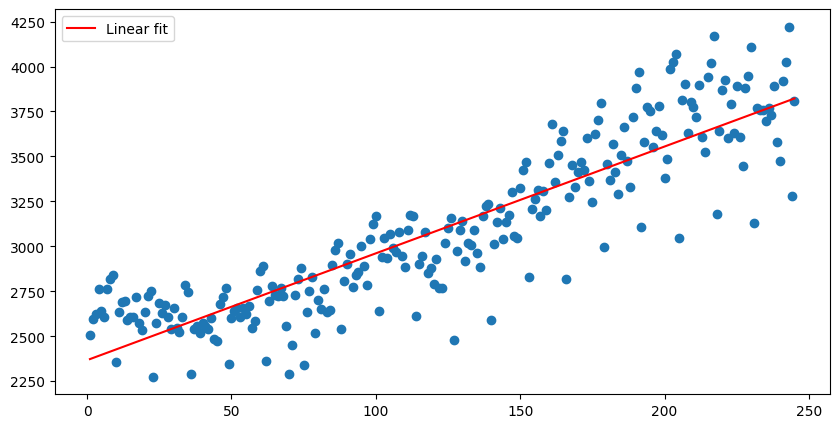

In [18]:
#Your code here
beta_1, beta_0 = np.polyfit(xvals, yvals, 1)  # Shown in Exercise book 2 that polyfit built-in funciton
#does the same thing as polyreg function in Exercise book 1 which uses least-sqaures

print(f'beta_0 = {beta_0:.3f}, beta_1 = {beta_1:.3f}')
# MSE
MSE = np.mean((yvals - (beta_0+beta_1*xvals))**2)
print(f'MSE = {MSE:.3f}')
# R2
R2 = 1 - MSE/np.var(yvals)
print(f'R2 = {R2:.3f}')

plt.rcParams['figure.figsize'] = [10, 5]
plt.scatter(xvals, yvals)
plt.plot(xvals, beta_0+beta_1*xvals,label= "Linear fit",color = "RED")
plt.legend()
plt.show()


## 3c)  Plotting the residuals

- Plot the residuals on a scatterplot
- Also plot the residuals over a short duration and comment on whether you can discern any periodic components.

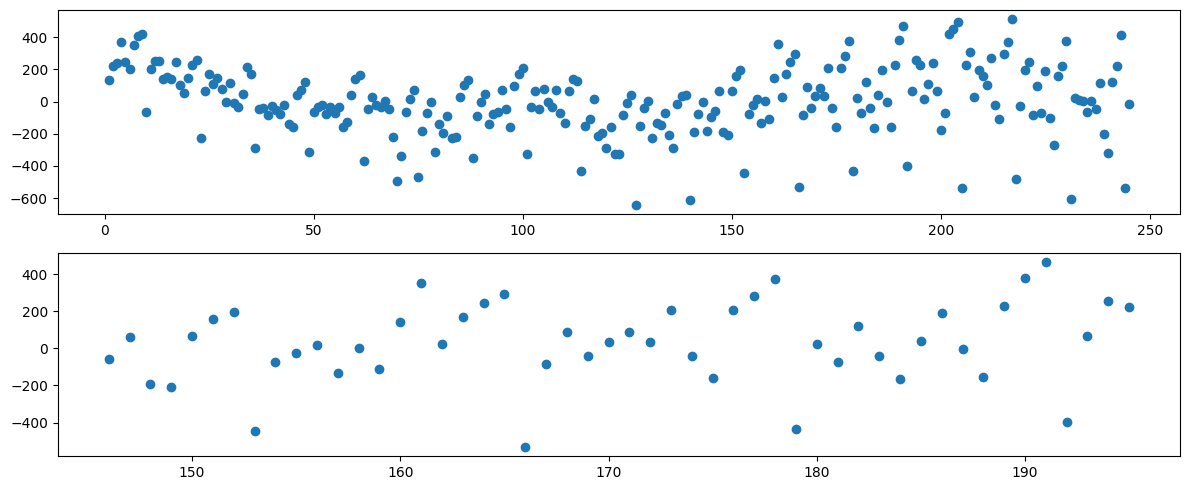

In [32]:
# Your code here
residuals_linear = yvals - (beta_0+beta_1*xvals)
plt.rcParams['figure.figsize'] = [12, 5]
plt.subplot(211)
plt.scatter(xvals, residuals_linear)
plt.subplot(212)
plt.scatter(xvals[145:195], residuals_linear[145:195])
plt.tight_layout()
plt.show()

Periodicity although less obvious than the hospital admission case, can be observerd. The periodicity can be described as: starting off around zero and staying close to zero for the first 14-17 units of x-measurement, then about 3 positive high amplitude point followed by one negative high amplitud point.

### 3d) Periodogram

- Compute and plot the peridogram of the residuals. (Recall that the periodogram is the squared-magnitude of the DFT coefficients.)
- Identify the indices/frequencies for which the periogram value exceeds **50%** of the maximum.


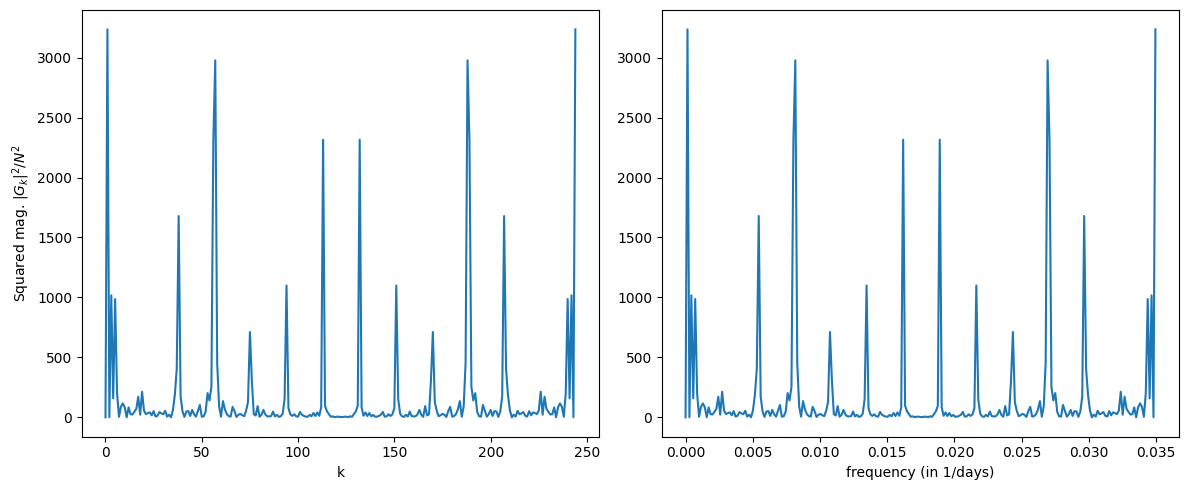

In [38]:
# Your code to compute and plot the periodogram
T = 28.5  # Time Interval between each consecutive sample
pgram = np.abs(np.fft.fft(residuals_linear, N)/N)**2 #We normalize by N, but this is optional
indices = np.linspace(0, (N-1), num = N)
freqs_in_hz = indices/(N*T)
freqs_in_rads = freqs_in_hz*2*math.pi

plt.subplot(121)
plt.plot(indices, pgram)
plt.xlabel('k')
plt.ylabel('Squared mag. $|G_k|^2/N^2$')
plt.subplot(122)
plt.plot(freqs_in_hz, pgram)
plt.xlabel('frequency (in 1/days)')  # Since units of T is days
plt.tight_layout()

In [40]:
# Your code to identify the indices for which the periodogram value exceeds 50% of the maximum
top_inds = indices[(pgram > 0.5*np.max(pgram))]
top_freqs_hz = freqs_in_hz[(pgram > 0.5*np.max(pgram))]
print('Top indices:', top_inds, ' Top frequencies in Hz:', top_freqs_hz)

Top indices: [  1.  38.  56.  57. 113. 132. 188. 189. 207. 244.]  Top frequencies in Hz: [0.00014322 0.00544218 0.00802005 0.00816327 0.01618332 0.0189044
 0.02692445 0.02706767 0.02964554 0.0349445 ]


## 3e) To the residuals,  fit a model of the form  

$$ \beta_{1s} \sin(\omega_1 x) + \beta_{1c} \cos(\omega_1 x) + \beta_{2s} \sin(\omega_2 x) + \beta_{2c} \cos(\omega_2 x) + \ldots + \beta_{Ks} \sin(\omega_K x) + \beta_{Kc} \cos(\omega_K x).$$

The frequencies $\omega_1, \ldots, \omega_K$ in the model are those corresponding to the indices identified in Part 2c. (Hint: Each of the sines and cosines will correspond to one column in your X-matrix.)

- Print the values of the regression coefficients obtained using least-squares.

All numerical outputs should be displayed to three decimal places.

In [70]:
# Your code here
w = top_freqs_hz*2*math.pi     # Angular velocities of the top frequencies

# Now form the X matrix with columns sin(wx) and cos(wx) for x in dates. First define its transpose
X = np.column_stack((np.sin(w[0]*xvals),np.cos(w[0]*xvals)))
for i in range(1,len(w)):
  X = np.column_stack((X,np.sin(w[i]*xvals),np.cos(w[i]*xvals)))
beta = np.linalg.lstsq(X, residuals_linear, rcond=None)[0]

# Output the coefficients
count = 1
sign = "s"
for i,coefficients in enumerate(beta):
  print(f'beta_{count}_{sign}={coefficients:.3f}')
  sign = "c" if sign == "s" else "s"  # Toggle sign between 's' and 'c'
  count = (i+1)//2 + 1

beta_1_s=1724.730
beta_1_c=-201.627
beta_2_s=280.570
beta_2_c=-119.248
beta_3_s=3926.664
beta_3_c=1804.687
beta_4_s=-3943.581
beta_4_c=-1281.229
beta_5_s=9.657
beta_5_c=-8.768
beta_6_s=-7.119
beta_6_c=61.690
beta_7_s=-348.542
beta_7_c=-105.972
beta_8_s=354.295
beta_8_c=70.405
beta_9_s=-11.709
beta_9_c=27.646
beta_10_s=-2.291
beta_10_c=4.727


### 3f) The combined fit
- Plot the combined fit together with a scatterplot of the data
- Compute and print the final **MSE** and $R^2$ coefficient. Comment on the improvement over the linear fit.

The combined fit, which corresponds to the full model

$$
f(x) = \beta_0 + \beta_1 x + \beta_{s1} \sin(\omega_1 x) + \beta_{c1} \cos(\omega_1 x) + \ldots + \beta_{sk} \sin(\omega_k x) + \beta_{ck} \cos(\omega_k x),
$$

can be obtained by adding the fits in parts 2b) and 2e).

New MSE = 33475.609
New R2 = 0.849


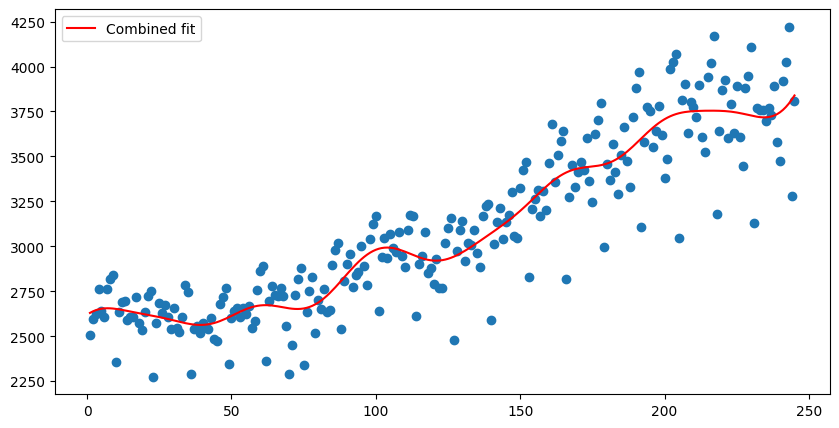

In [73]:
# Your code here
y = beta_0 + beta_1*xvals + np.dot(X,beta)
new_MSE = np.mean((yvals - y)**2)
print(f'New MSE = {new_MSE:.3f}')
new_R2 = 1 - new_MSE/np.var(yvals)
print(f'New R2 = {new_R2:.3f}')
plt.rcParams['figure.figsize'] = [10, 5]
plt.scatter(xvals, yvals)
plt.plot(xvals, y,label = "Combined fit",color = "RED")
plt.legend()
plt.show()

From MSE and R^2, we can see clearly that the model is greatly imporved by the additional osciilatory component.